<a href="https://colab.research.google.com/github/mridulasrinivasula-svg/OPTN-Model/blob/main/Wt_simulation_and_calibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATA ALIGNMENT CHECK
D_all(1995) = 8,859
D_all(2024) = 24,020
D_all(2025) = 23,790

BETA_ALL CALIBRATION RESULTS
Initial W(1995):     43,370
Target W(2025):      100,000
Calibrated beta_all: 2.1763777670
Model W(2025):       100,000.00
Calibration error:   -0.0000000000

YEARLY WAITLIST RESULTS
Year | Waitlist
------------------------------
1995 | 43,370
1996 | 48,430
1997 | 53,168
1998 | 58,121
1999 | 63,219
2000 | 67,250
2001 | 69,967
2002 | 70,396
2003 | 68,151
2004 | 67,353
2005 | 68,034
2006 | 68,216
2007 | 69,921
2008 | 72,359
2009 | 74,814
2010 | 78,264
2011 | 82,971
2012 | 86,059
2013 | 90,137
2014 | 95,487
2015 | 99,268
2016 | 98,775
2017 | 98,203
2018 | 97,507
2019 | 98,766
2020 | 100,579
2021 | 98,792
2022 | 98,311
2023 | 97,827
2024 | 97,630
2025 | 100,000

YEARLY TRANSPLANT RESULTS
Year | D_all | T_all
------------------------------
1995 | 8,859 | 19,281
1996 | 9,222 | 20,071
1997 | 9,546 | 20,776
1998 | 10,363 | 22,554
1999 | 10,872 | 23,662
2000 | 11,942 | 25,990
2001 | 

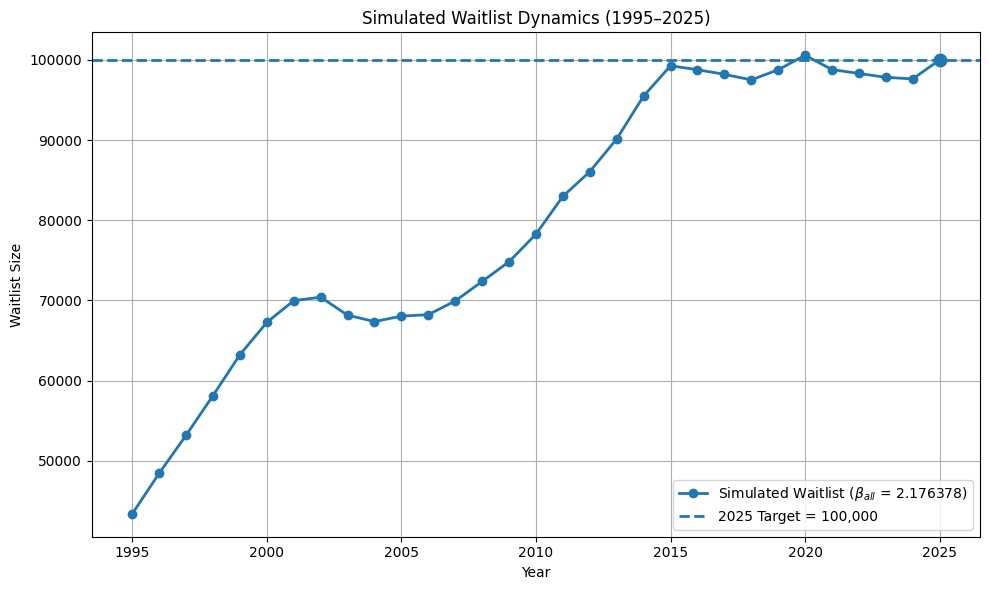

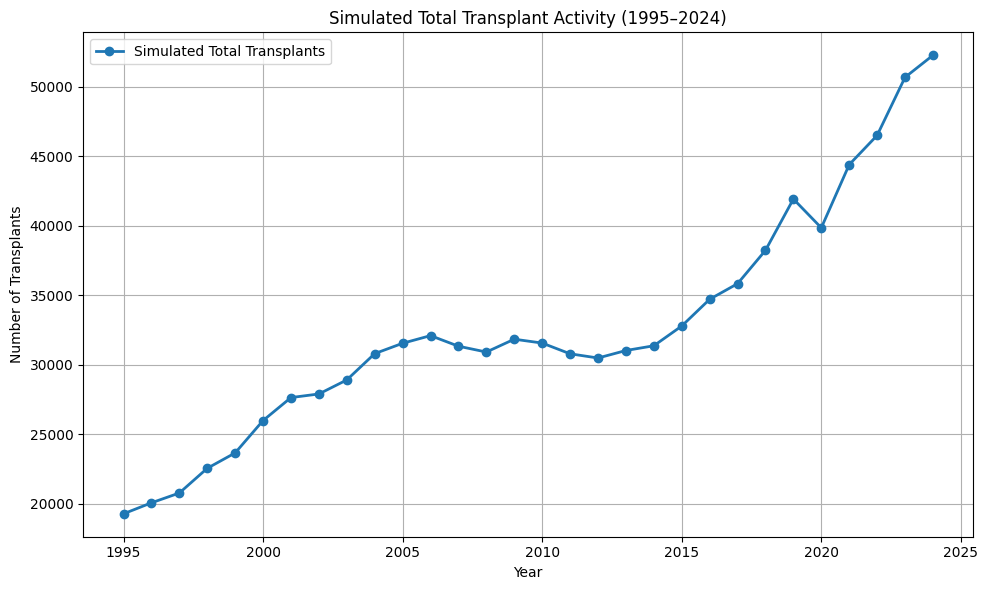

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ============================================================
# BETA_ALL CALIBRATION FOR WAITLIST MODEL
# ============================================================

# ------------------------------------------------------------
# 1. INITIAL CONDITION
# ------------------------------------------------------------

W0 = 43370

# Target 2025 waitlist
TARGET_W_2025 = 100000


# ------------------------------------------------------------
# 2. YEARS
# ------------------------------------------------------------

years = np.arange(1995, 2026)


# ------------------------------------------------------------
# 3. WAITLIST ADDITIONS A(t)
# 1995–2024
# ------------------------------------------------------------

A = np.array([
    33095, 34070, 35604, 38494, 40803, 42844, 42828,
    42100, 43498, 47040, 48943, 51568, 52807, 53402,
    54849, 56414, 55059, 56318, 58683, 58862, 57632,
    58903, 59683, 63646, 66819, 60086, 66196, 68459,
    73013, 77074
], dtype=float)


# ------------------------------------------------------------
# 4. WAITLIST REMOVALS R(t)
# 1995–2024
# ------------------------------------------------------------

R = np.array([
    8754, 9262, 9875, 10842, 13111, 14137, 14754,
    16442, 15383, 15552, 17210, 17762, 19029, 20027,
    19554, 20141, 21177, 21749, 22303, 23708, 25331,
    24758, 24538, 24148, 23074, 22015, 22270, 22432,
    22520, 22427
], dtype=float)


# ------------------------------------------------------------
# 5. TOTAL DONORS D_all(t)
#
# Original data was given:
# 2025 -> 1995
#
# We reverse it so it matches:
# 1995 -> 2025
# ------------------------------------------------------------

D_all_reverse = np.array([
    23790, 24020, 23291, 21371, 20404, 18314, 19267,
    17570, 16468, 15952, 15068, 14415, 14258, 14010,
    14149, 14504, 14632, 14207, 14400, 14750, 14497,
    14155, 13285, 12821, 12702, 11942, 10872, 10363,
    9546, 9222, 8859
], dtype=float)

# Reverse the array
D_all = D_all_reverse[::-1]

# D_all now runs from 1995 -> 2025


# ============================================================
# CHECK DATA ALIGNMENT
# ============================================================

print("=" * 70)
print("DATA ALIGNMENT CHECK")
print("=" * 70)

print(f"D_all(1995) = {D_all[0]:,.0f}")
print(f"D_all(2024) = {D_all[-2]:,.0f}")
print(f"D_all(2025) = {D_all[-1]:,.0f}")

print("=" * 70)


# ============================================================
# 6. WAITLIST MODEL
#
# W(t+1) = W(t) + A(t) - T_all(t) - R(t)
#
# T_all(t) = beta_all * D_all(t)
# ============================================================

def run_model(beta_all):

    W = np.zeros(len(years))

    # 30 yearly transplant values:
    # 1995 -> 2024
    T_all = np.zeros(len(A))

    W[0] = W0

    for t in range(len(A)):

        # Total transplant equation
        T_all[t] = beta_all * D_all[t]

        # Waitlist equation
        W[t + 1] = (
            W[t]
            + A[t]
            - T_all[t]
            - R[t]
        )

    return W, T_all


# ============================================================
# 7. CALIBRATION ERROR
# ============================================================

def calibration_error(beta_all):

    W, T_all = run_model(beta_all)

    # W[-1] = W(2025)
    return W[-1] - TARGET_W_2025


# ============================================================
# 8. CALIBRATE BETA_ALL
# ============================================================

BETA_ALL = brentq(
    calibration_error,
    0.1,
    5.0
)


# ============================================================
# 9. RUN FINAL CALIBRATED MODEL
# ============================================================

W, T_all = run_model(BETA_ALL)


# ============================================================
# 10. PRINT CALIBRATION RESULTS
# ============================================================

print()
print("=" * 70)
print("BETA_ALL CALIBRATION RESULTS")
print("=" * 70)

print(f"Initial W(1995):     {W0:,.0f}")
print(f"Target W(2025):      {TARGET_W_2025:,.0f}")
print(f"Calibrated beta_all: {BETA_ALL:.10f}")
print(f"Model W(2025):       {W[-1]:,.2f}")
print(
    f"Calibration error:   "
    f"{W[-1] - TARGET_W_2025:,.10f}"
)

print("=" * 70)


# ============================================================
# 11. YEARLY WAITLIST RESULTS
# ============================================================

print()
print("YEARLY WAITLIST RESULTS")
print("=" * 70)

print("Year | Waitlist")
print("-" * 30)

for t in range(len(years)):

    print(
        f"{years[t]} | "
        f"{W[t]:,.0f}"
    )


# ============================================================
# 12. TRANSPLANT RESULTS
# ============================================================

print()
print("YEARLY TRANSPLANT RESULTS")
print("=" * 70)

print("Year | D_all | T_all")
print("-" * 30)

for t in range(len(A)):

    print(
        f"{years[t]} | "
        f"{D_all[t]:,.0f} | "
        f"{T_all[t]:,.0f}"
    )


# ============================================================
# 13. WAITLIST GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    years,
    W,
    marker="o",
    linewidth=2,
    label=f"Simulated Waitlist ($\\beta_{{all}}$ = {BETA_ALL:.6f})"
)

plt.axhline(
    TARGET_W_2025,
    linestyle="--",
    linewidth=2,
    label="2025 Target = 100,000"
)

plt.scatter(
    2025,
    W[-1],
    s=80,
    zorder=5
)

plt.xlabel("Year")
plt.ylabel("Waitlist Size")
plt.title("Simulated Waitlist Dynamics (1995–2025)")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Beta_All_Waitlist_Calibration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. TOTAL TRANSPLANT GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    years[:-1],
    T_all,
    marker="o",
    linewidth=2,
    label="Simulated Total Transplants"
)

plt.xlabel("Year")
plt.ylabel("Number of Transplants")
plt.title("Simulated Total Transplant Activity (1995–2024)")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Beta_All_Transplant_Calibration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

